In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "bot")
from config import ASSETS, CACHE_DIR

In [2]:
figi = ASSETS["SBERP"]

df_1m = pd.read_csv(CACHE_DIR / f"{figi}_1min.csv", parse_dates=["timestamp"])
df_5m = pd.read_csv(CACHE_DIR / f"{figi}_5min.csv", parse_dates=["timestamp"])

print(f"1min: {len(df_1m):>7,} bars  {df_1m.timestamp.min()} .. {df_1m.timestamp.max()}")
print(f"5min: {len(df_5m):>7,} bars  {df_5m.timestamp.min()} .. {df_5m.timestamp.max()}")
df_1m.head()

1min: 313,913 bars  2025-01-02 04:00:00+00:00 .. 2025-12-31 20:47:00+00:00
5min:  74,395 bars  2025-01-02 04:00:00+00:00 .. 2025-12-31 20:45:00+00:00


,timestamp,open,high,low,close,volume
0,2025-01-02 04:00:00+00:00,272.51,272.51,272.50,272.50,160
1,2025-01-02 04:02:00+00:00,275.25,275.25,275.25,275.25,10
2,2025-01-02 04:04:00+00:00,279.20,279.20,279.20,279.20,20
3,2025-01-02 04:05:00+00:00,279.21,279.22,278.76,278.76,130
4,2025-01-02 04:07:00+00:00,280.00,280.01,279.00,279.00,60


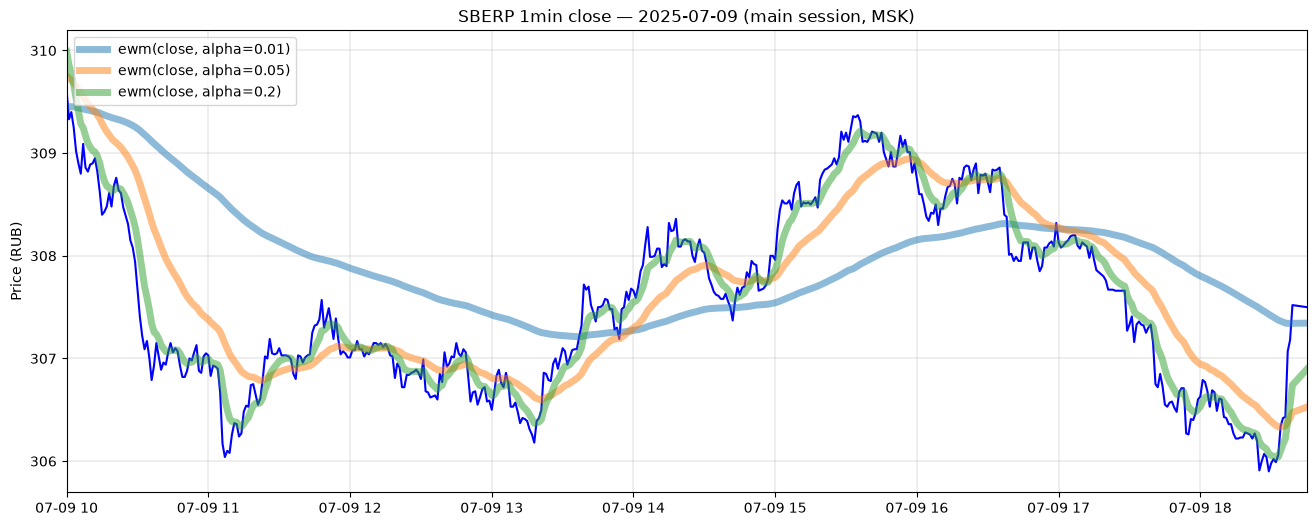

In [3]:
# One day of 1min candles + EWM trends of close, main MOEX session only, MSK time.
DAY = df_1m.timestamp.dt.date.values[150_000]  # pick any cached date here
ALPHAS = [0.01, 0.05, 0.2]

# MOEX time = Moscow (UTC+3). Drop the tz after converting so matplotlib
# shows MSK wall time on the axis instead of converting back to UTC.
ts_msk = df_1m.timestamp.dt.tz_convert("Europe/Moscow").dt.tz_localize(None)

# Main trading session: 10:00-18:45 MSK (excludes morning/evening sessions).
t = ts_msk.dt.time
in_main = (t >= pd.Timestamp("10:00").time()) & (t <= pd.Timestamp("18:45").time())

# EWM over the full series so the trend has warmup before the displayed day.
ewms = {a: df_1m["close"].ewm(alpha=a).mean() for a in ALPHAS}

day = df_1m[(ts_msk.dt.date == DAY) & in_main]
day_ts = ts_msk[day.index]
# up = day["close"] >= day["open"]
# colors = np.where(up, "seagreen", "tomato")

fig, ax = plt.subplots(figsize=(16, 6))

# ax.vlines(day_ts, day["low"], day["high"], color=colors, lw=0.5)
# body_lo = np.minimum(day["open"], day["close"])
# body_hi = np.maximum(day["open"], day["close"])
# ax.vlines(day_ts, body_lo, body_hi, color=colors, lw=2.5)

ax.plot(day_ts, day["close"], color="blue")
for a in ALPHAS:
    ax.plot(day_ts, ewms[a][day.index], lw=5, alpha=0.5, label=f"ewm(close, alpha={a})")

ax.set_title(f"SBERP 1min close — {DAY} (main session, MSK)")
ax.set_ylabel("Price (RUB)")
ax.legend(loc="upper left")
ax.grid(True, lw=0.3)
ax.margins(x=0)
plt.show()